# 早期强势股 V4 开发区审计

## tl;dr

- V4 在 2018–2023 开发区被正式判为 `DEVELOPMENT_REJECTED`，没有打开 2024/2025 冻结验证集，也没有交易权限。
- 新标签快照包含 155,107 行、307 个周截面和 1,441 只证券；粒度、点时、交易日历、ForwardFactor 与执行时点审计通过。
- ML 在 2020–2023 四个滚动样本外年份均未通过门禁；2021–2023 的 Precision@20 低于 RS60，2020/2023 的部分相位实际投资周期不足。
- 当前历史母表来自“今天仍可见”的 TDX 证券列表。交易所终止上市名单对账发现历史证券缺失，因此结果只能用于开发诊断，不能用于晋级或宣称全 A 表现。

## Context & Methods

### Key assumptions

- 决策时点：每周最后一个交易日收盘；只读入当时已经生效的数据。
- 执行标签：下一交易日开盘进入，第 40 个市场交易日后的下一开盘退出；未复权价执行、ForwardFactor 计算总收益。
- 组合：Top20、行业最多 5 只；次日不可成交的入选槽位留现金且不回填。
- 评价：8 个起始相位；候选与 RS60 使用共同的最晚资金可用边界；20bp 基础成本和 40bp 双倍成本。
- 本 Notebook 明确拒绝读取 2024、2025、2026 的行情、特征或结果。

In [1]:
from pathlib import Path
import json
import sqlite3
import hashlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

from research_platform.early_winner_v4_research import (
    TECHNICAL_FEATURES,
    prepare_v4_labels,
)

ROOT = Path.cwd()
SNAPSHOT_PREFIX = "ewv4f_05b1a6ec6218d7e59027_"
AUDIT_ID = "ewv4_dev_837bd0a4b015422a493c6918"
files = sorted((ROOT / "data/research/early_winner_v4/features").glob(f"{SNAPSHOT_PREFIX}*.parquet"))
assert len(files) == 6, files
assert {int(path.stem[-4:]) for path in files} == set(range(2018, 2024))
frame = pd.concat([pd.read_parquet(path) for path in files], ignore_index=True)
frame = prepare_v4_labels(frame)
assert pd.to_datetime(frame["asof"]).dt.year.max() <= 2023
assert not frame.duplicated(["asof", "code"]).any()

connection = sqlite3.connect(ROOT / "data/research.db")
connection.row_factory = sqlite3.Row
validation = dict(connection.execute(
    "SELECT * FROM research_validations WHERE validation_id=?", (AUDIT_ID,)
).fetchone())
ml = json.loads(validation["ml_metrics_json"])
baseline = json.loads(validation["baseline_metrics_json"])
print({"rows": len(frame), "weeks": frame["asof"].nunique(), "codes": frame["code"].nunique(), "status": validation["status"]})

{'rows': 155107, 'weeks': 307, 'codes': 1441, 'status': 'DEVELOPMENT_REJECTED'}


## Data

纳入母体内部的数据质量足以复算开发诊断：主键无重复、必需特征无缺失、成熟标签有实际退出且时点关系正确。249 行对应的 6 只状态历史全空证券被明确排除，未使用价格推算静默替代。这个结论不消除历史退市证券缺失造成的幸存者偏差。

In [2]:
quality = pd.DataFrame({
    "metric": [
        "rows", "decision_weeks", "codes", "duplicate_grain_rows",
        "status_complete_rows", "status_incomplete_rows", "mature_labeled_rows",
    ],
    "value": [
        len(frame), frame["asof"].nunique(), frame["code"].nunique(),
        int(frame.duplicated(["asof", "code"]).sum()),
        int(frame.execution_status_complete.sum()),
        int((~frame.execution_status_complete).sum()),
        int(frame.forward_return_40.notna().sum()),
    ],
})
quality

,metric,value
0,rows,155107
1,decision_weeks,307
2,codes,1441
3,duplicate_grain_rows,0
4,status_complete_rows,154858
5,status_incomplete_rows,249
6,mature_labeled_rows,148459


In [3]:
year_quality = frame.groupby(pd.to_datetime(frame["asof"]).dt.year).agg(
    rows=("code", "size"),
    weeks=("asof", "nunique"),
    codes=("code", "nunique"),
    status_complete_rate=("execution_status_complete", "mean"),
    label_window_mature_rate=("label_window_matured", "mean"),
).round(4)
year_quality

,rows,weeks,codes,status_complete_rate,label_window_mature_rate
asof,,,,,
2018,13187,51,620,0.9986,0.9631
2019,19048,52,829,0.9987,0.9948
2020,28885,52,984,0.9988,0.9960
2021,29845,52,1061,0.9995,0.9975
2022,32630,50,1225,0.9980,0.9975
2023,31512,50,1247,0.9972,0.8163


## Results

V4 没有显示出跨年稳定性。以下分组柱状图用每个年度 8 相位复合结果比较 ML 与 RS60；2020 的 ML 相对基准更少亏损，但 2021–2023 没有形成可晋级的持续优势。所有年度的 ML 双倍成本收益均为负。

In [4]:
year_rows = []
for year in sorted(ml["yearly"]):
    candidate = ml["yearly"][year]
    reference = baseline["yearly"][year]
    year_rows.extend([
        {"year": int(year), "method": "ML", "total_return": candidate["total_return"],
         "double_cost_return": candidate["double_cost_return"], "precision_at_20": candidate["precision_at_20"],
         "min_invested_periods": candidate["min_phase_invested_periods"], "max_drawdown": candidate["max_drawdown"]},
        {"year": int(year), "method": "RS60", "total_return": reference["total_return"],
         "double_cost_return": reference["double_cost_return"], "precision_at_20": reference["precision_at_20"],
         "min_invested_periods": reference["min_phase_invested_periods"], "max_drawdown": reference["max_drawdown"]},
    ])
year_metrics = pd.DataFrame(year_rows)
year_metrics.pivot(index="year", columns="method", values=["total_return", "precision_at_20", "min_invested_periods"]).round(4)

total_return         precision_at_20         min_invested_periods     
method           ML    RS60              ML    RS60                   ML RS60
year                                                                         
2020        -0.0381 -0.1967          0.1135  0.0981                  1.0  1.0
2021        -0.0467 -0.0654          0.1000  0.1429                  3.0  3.0
2022        -0.0928 -0.0983          0.1200  0.1775                  2.0  2.0
2023        -0.0222  0.0267          0.1346  0.1808                  1.0  1.0

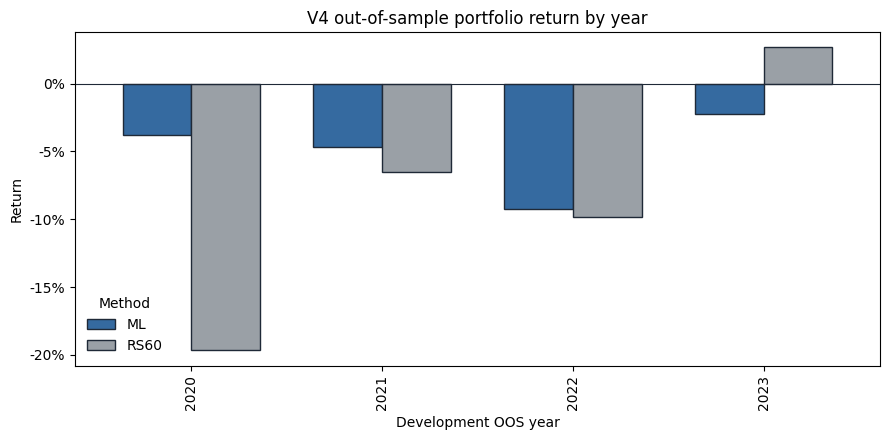

In [5]:
pivot = year_metrics.pivot(index="year", columns="method", values="total_return")
ax = pivot[["ML", "RS60"]].plot.bar(
    color=["#356AA0", "#9AA0A6"], edgecolor="#1F2937", width=0.72, figsize=(9, 4.5)
)
ax.axhline(0, color="#1F2937", linewidth=0.8)
ax.set_title("V4 out-of-sample portfolio return by year")
ax.set_xlabel("Development OOS year")
ax.set_ylabel("Return")
ax.yaxis.set_major_formatter(lambda value, position: f"{value:.0%}")
ax.legend(title="Method", frameon=False)
plt.tight_layout()
plt.show()

最小相位样本门禁同样失败。`min_invested_periods` 是 8 个相位中最少的实际投资周期数，预注册下限为 2；2020 和 2023 只有 1。这里不以降低门槛来补救，因为那会在看过结果后改变规则。

In [6]:
phase_sample = year_metrics.pivot(index="year", columns="method", values="min_invested_periods")
phase_sample

method,ML,RS60
year,,
2020,1,1
2021,3,3
2022,2,2
2023,1,1


## Most momentum features are unstable or negatively aligned

逐年 Spearman IC 与十分位差显示，原 15 特征族没有提供稳定的 40 日正向排序能力。`event_score` 的平均 IC 略为正，但强度很小；60 日收益、相对强度和价格偏离 MA60 的平均 IC 为负。高相关特征对还说明模型重复使用了近似相同的信息。

In [7]:
feature_rows = []
eligible = frame.loc[
    frame.v4_eligible & frame.entry_executable & frame.forward_return_40.notna()
].copy()
for year, group in eligible.groupby("year"):
    for feature in TECHNICAL_FEATURES:
        weekly_ic = []
        weekly_spread = []
        for _, weekly in group.groupby("asof"):
            values = pd.to_numeric(weekly[feature], errors="coerce")
            future_return = pd.to_numeric(weekly.forward_return_40, errors="coerce")
            valid = values.notna() & future_return.notna()
            if valid.sum() < 3 or values[valid].nunique() <= 1 or future_return[valid].nunique() <= 1:
                continue
            weekly_ic.append(spearmanr(values[valid], future_return[valid]).statistic)
            ranks = values[valid].rank(pct=True)
            weekly_spread.append(
                future_return.loc[ranks.index[ranks >= .8]].mean()
                - future_return.loc[ranks.index[ranks <= .2]].mean()
            )
        feature_rows.append({
            "year": int(year), "feature": feature,
            "ic": np.mean(weekly_ic) if weekly_ic else np.nan,
            "top_bottom_spread": np.mean(weekly_spread) if weekly_spread else np.nan,
            "weeks": len(weekly_ic),
        })
feature_by_year = pd.DataFrame(feature_rows)
feature_summary = feature_by_year.groupby("feature").agg(
    mean_ic=("ic", "mean"), min_ic=("ic", "min"), max_ic=("ic", "max"),
    positive_years=("ic", lambda values: int((values > 0).sum())),
    mean_top_bottom_spread=("top_bottom_spread", "mean"),
).sort_values("mean_ic", ascending=False)
feature_summary.round(4)

,mean_ic,min_ic,max_ic,positive_years,mean_top_bottom_spread
feature,,,,,
event_score,0.0165,-0.0446,0.0398,5,-0.0036
breakout_distance,0.0080,-0.0835,0.0793,4,0.0077
relative_return_120,0.0055,-0.1293,0.1822,3,0.0203
return_120,0.0055,-0.1293,0.1822,3,0.0203
industry_momentum,-0.0212,-0.1205,0.0611,3,0.0134
industry_breadth,-0.0279,-0.0935,0.0095,2,0.0104
return_60,-0.0352,-0.1364,0.0798,3,0.0083
relative_return_60,-0.0352,-0.1364,0.0798,3,0.0083
volume_ratio,-0.0355,-0.0728,-0.0030,0,-0.0054


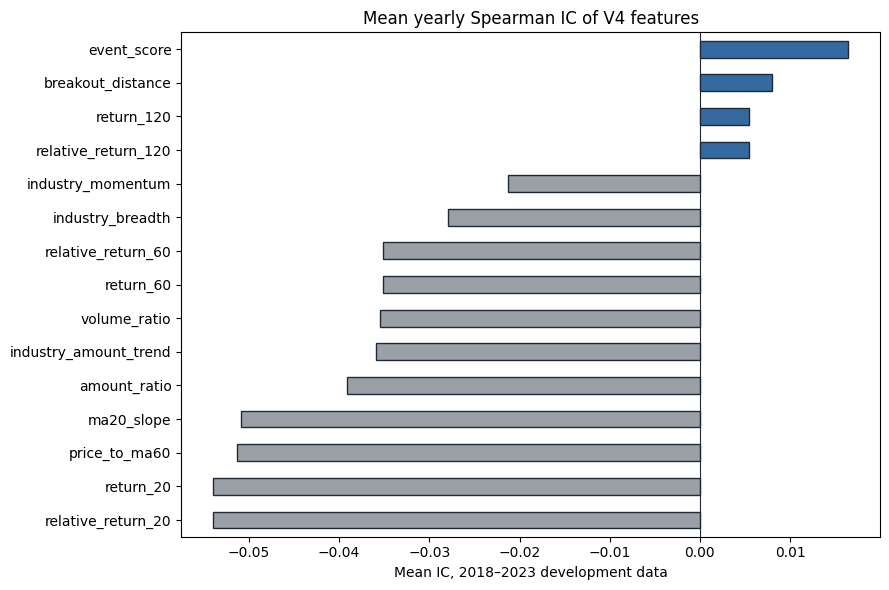

In [8]:
plot_data = feature_summary.sort_values("mean_ic")
colors = ["#356AA0" if value >= 0 else "#9AA0A6" for value in plot_data.mean_ic]
ax = plot_data.mean_ic.plot.barh(color=colors, edgecolor="#1F2937", figsize=(9, 6))
ax.axvline(0, color="#1F2937", linewidth=0.8)
ax.set_title("Mean yearly Spearman IC of V4 features")
ax.set_xlabel("Mean IC, 2018–2023 development data")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

In [9]:
correlation = eligible[list(TECHNICAL_FEATURES)].corr(method="spearman")
redundant_pairs = []
for position, left in enumerate(TECHNICAL_FEATURES):
    for right in TECHNICAL_FEATURES[position + 1:]:
        value = correlation.loc[left, right]
        if abs(value) >= .85:
            redundant_pairs.append({"left": left, "right": right, "spearman": value})
pd.DataFrame(redundant_pairs).sort_values("spearman", key=abs, ascending=False).round(3)

,left,right,spearman
5,volume_ratio,amount_ratio,0.991
3,return_120,relative_return_120,0.929
1,return_20,ma20_slope,0.925
0,return_20,relative_return_20,0.921
2,return_60,relative_return_60,0.888
4,relative_return_20,ma20_slope,0.851


## Limitations, uncertainty, and robustness checks

- **Promotion blocker — historical universe:** 当前 TDX 母表不包含已终止上市证券；V4 对缺失母体无法计算技术、财务和事件特征。这是高严重度幸存者偏差风险。
- **Small effective sample:** 40 日持有、共同资金边界和市场广度门槛使每个相位只有 4–6 个周期，2020/2023 的最差相位仅 1 个实际投资周期。
- **Training target caveat:** 训练标签只存在于次日可成交样本，虽然排名阶段不使用次日可成交性，但训练分布仍条件化于未来执行结果。正式 V5 应将成熟但不可成交的决策样本定义为不可捕获目标或采用两阶段模型。
- **MDD lower bound:** 当前组合回撤为周期端点净值回撤；正式部署证据仍需要逐日盯市账簿和完整退出规则。
- **No frozen-set claim:** 本审计没有读取 2024/2025；任何 V5 变更必须先在 2018–2023 固定，再一次性开启冻结验证。

## Recommended next steps

1. 用交易所官方终止上市名单建立版本化历史证券母表，并补齐缺失证券的历史行情；若 TDX 无法提供，必须先立项批准一个可追溯的备用行情源。
2. 重建 2018–2023 特征与标签，量化幸存者偏差对候选排名、行业广度和收益的影响。
3. V5 只保留少量低冗余信号，显式惩罚 60 日过热；采用一次性预注册的开发协议，不在 2024/2025 上调参。
4. 将周末候选后次日不可成交定义为现金结果，并把逐日持仓账簿、MA60/重大负面/回撤退出纳入组合验证。

## Further questions

- 交易所历史证券母表能否与一个可靠的退市证券历史行情源完整对齐？
- 在补齐历史母体后，原先的负动量 IC 是真实的过热反转，还是幸存者偏差造成？
- 市场广度门槛导致的低投资频率是否与“每周候选”的交易目标一致？